Present value of future cash flows 

Bond cash flow modelling

Discounting using spot rates

Yield vs Spot rate

Clean pricing implementation

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline

In [18]:
from pathlib import Path

ROOT = Path.cwd().parent

In [19]:
curve = pd.read_csv(ROOT / "data/continuous_zero_curve.csv")

curve.head()

,Years,Spot
0,0.250000,3.830000
1,0.309619,3.872708
2,0.369238,3.907414
3,0.428858,3.935034
4,0.488477,3.956488


In [20]:
# Interpolation for any maturity
spot_curve = CubicSpline(
    curve["Years"],
    curve["Spot"]
)

In [21]:
def discount_factor(t):

    r = spot_curve(t) / 100

    return 1 / (1 + r)**t


In [22]:
# Bond pricing (zeros)
def price_zero(face, maturity):
    return face * discount_factor(maturity)

In [23]:
# Coupon bond pricing
# Future cash flow generator
def cashflows(maturity, coupon_rate, freq = 2, face = 100):

    periods = int(maturity * freq)

    payment = (coupon_rate / 100 * face / freq)

    times = np.arange(1, periods+1) / freq

    cashflows = np.full(
        periods,
        payment
    )

    cashflows[-1] += face

    return times, cashflows

times, cf = cashflows(maturity = 5, coupon_rate = 4)

pd.DataFrame({
    "Time": times,
    "Cashflow": cf
})

,Time,Cashflow
0,0.5,2.0
1,1.0,2.0
2,1.5,2.0
3,2.0,2.0
4,2.5,2.0
5,3.0,2.0
6,3.5,2.0
7,4.0,2.0
8,4.5,2.0
9,5.0,102.0


In [24]:
def price_bond(maturity, coupon_rate, face = 100, frequency = 2):

    times, cf = cashflows(maturity, coupon_rate, frequency,face)

    dfs = discount_factor(times)

    return np.sum(cf * dfs)

In [25]:
# Pricing Examples
portfolio = pd.DataFrame({

    "Maturity":[2,5,7,10,20],
    "Coupon":[3.5,4,4.25,4.5,5]

})

portfolio["Price"] = portfolio.apply(

    lambda x: price_bond(x["Maturity"], x["Coupon"]),

    axis=1
)

portfolio

,Maturity,Coupon,Price
0,2,3.50,98.744646
1,5,4.00,98.793471
2,7,4.25,99.100718
3,10,4.50,99.678983
4,20,5.00,99.231082


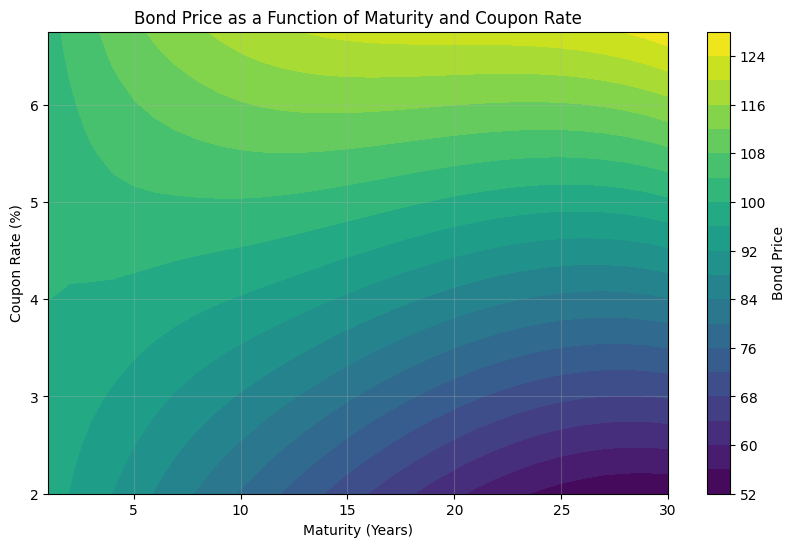

In [26]:
# Price surface
maturity = np.arange(1, 31)

coupon = np.arange(2, 7, 0.25)

prices = np.zeros((len(coupon), len(maturity)))

for i,c in enumerate(coupon):

    for j,m in enumerate(maturity):

        prices[i,j] = price_bond(m, c) # Matrix

plt.figure(figsize=(10, 6))

contour = plt.contourf(
    maturity,
    coupon,
    prices,
    levels=20,
    cmap="viridis"
)

plt.colorbar(contour, label="Bond Price")

plt.xlabel("Maturity (Years)")
plt.ylabel("Coupon Rate (%)")
plt.title("Bond Price as a Function of Maturity and Coupon Rate")

plt.grid(alpha=0.3)

plt.show()

In [28]:
portfolio.to_csv(ROOT / "data/sample_portfolio.csv", index = False)